In [1]:
import os

import matplotlib.pyplot as plt
import sinter

from qecdec.experiments import RotatedSurfaceCode_Memory
from qecdec.slwin import SlidingWindowDecoder
from qecdec.sinter_utils import QecdecSinterDecoder

In [2]:
total_rounds = 50
commit_size = 1
const_window_size = 3


def generate_sinter_tasks_and_custom_decoders():
    tasks: list[sinter.Task] = []
    custom_decoders: dict[str, sinter.Decoder] = {}
    for d in [5, 7, 9, 11]:
        for p in [0.01, 0.02, 0.03, 0.04, 0.05]:
            # Setup the experiment.
            expmt = RotatedSurfaceCode_Memory(
                d=d,
                rounds=total_rounds,
                basis="Z",
                data_qubit_error_rate=p,
                meas_error_rate=p,
            )

            sw_d_window_size = SlidingWindowDecoder.from_pcm_prior(
                expmt.chkmat,
                expmt.prior,
                detectors_per_layer=expmt.num_detectors_per_layer,
                window_size=d,
                commit_size=commit_size,
            )
            sw_d_window_size.configure_inner_decoders("MWPM")
            custom_decoder_id = f"custom_decoder_{len(custom_decoders)}"
            custom_decoders[custom_decoder_id] = QecdecSinterDecoder(
                sw_d_window_size, expmt.obsmat
            )
            tasks.append(
                sinter.Task(
                    circuit=expmt.circuit,
                    detector_error_model=expmt.dem,
                    decoder=custom_decoder_id,
                    json_metadata={
                        "d": d,
                        "p": p,
                        "window_size": d,
                        "group": "d_window_size",
                    },
                )
            )

            sw_const_window_size = SlidingWindowDecoder.from_pcm_prior(
                expmt.chkmat,
                expmt.prior,
                detectors_per_layer=expmt.num_detectors_per_layer,
                window_size=const_window_size,
                commit_size=commit_size,
            )
            sw_const_window_size.configure_inner_decoders("MWPM")
            custom_decoder_id = f"custom_decoder_{len(custom_decoders)}"
            custom_decoders[custom_decoder_id] = QecdecSinterDecoder(
                sw_const_window_size, expmt.obsmat
            )
            tasks.append(
                sinter.Task(
                    circuit=expmt.circuit,
                    detector_error_model=expmt.dem,
                    decoder=custom_decoder_id,
                    json_metadata={
                        "d": d,
                        "p": p,
                        "window_size": const_window_size,
                        "group": "const_window_size",
                    },
                )
            )

    return tasks, custom_decoders


tasks, custom_decoders = generate_sinter_tasks_and_custom_decoders()

In [3]:
sinter_stats = sinter.collect(
    num_workers=os.cpu_count() - 1,
    max_shots=10_000_000,
    max_errors=100,
    tasks=tasks,
    custom_decoders=custom_decoders,
    print_progress=False,
)

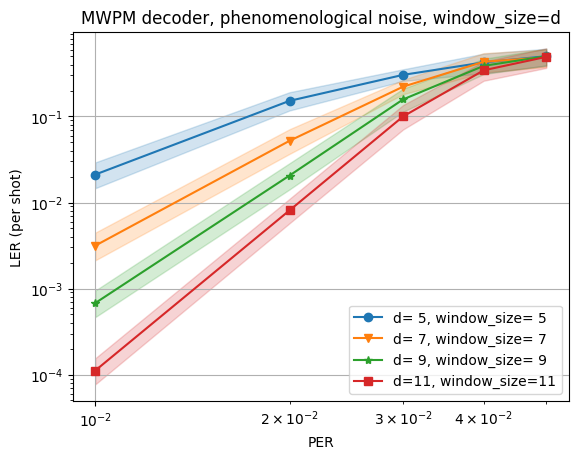

In [4]:
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=sinter_stats,
    group_func=lambda stat: (
        f"d={stat.json_metadata['d']:2d}, window_size={stat.json_metadata['window_size']:2d}"
    ),
    filter_func=lambda stat: stat.json_metadata["group"] == "d_window_size",
    x_func=lambda stat: stat.json_metadata["p"],
)
ax.loglog()
ax.grid()
ax.set_ylabel("LER (per shot)")
ax.set_xlabel("PER")
ax.set_title("MWPM decoder, phenomenological noise, window_size=d")
ax.legend()

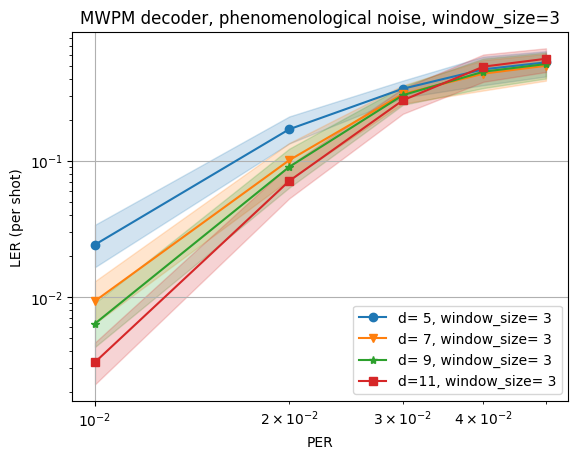

In [5]:
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=sinter_stats,
    group_func=lambda stat: (
        f"d={stat.json_metadata['d']:2d}, window_size={stat.json_metadata['window_size']:2d}"
    ),
    filter_func=lambda stat: stat.json_metadata["group"] == "const_window_size",
    x_func=lambda stat: stat.json_metadata["p"],
)
ax.loglog()
ax.grid()
ax.set_ylabel("LER (per shot)")
ax.set_xlabel("PER")
ax.set_title(f"MWPM decoder, phenomenological noise, window_size={const_window_size}")
ax.legend()

In [6]:
def generate_sinter_tasks_and_custom_decoders():
    tasks: list[sinter.Task] = []
    custom_decoders: dict[str, sinter.Decoder] = {}
    d = 9
    p = 0.01
    total_rounds = 50
    commit_size = 1

    # Setup the experiment.
    expmt = RotatedSurfaceCode_Memory(
        d=d,
        rounds=total_rounds,
        basis="Z",
        data_qubit_error_rate=p,
        meas_error_rate=p,
    )

    for window_size in range(3, total_rounds + 1):
        sw = SlidingWindowDecoder.from_pcm_prior(
            expmt.chkmat,
            expmt.prior,
            detectors_per_layer=expmt.num_detectors_per_layer,
            window_size=window_size,
            commit_size=commit_size,
        )
        sw.configure_inner_decoders("MWPM")
        custom_decoder_id = f"custom_decoder_{len(custom_decoders)}"
        custom_decoders[custom_decoder_id] = QecdecSinterDecoder(sw, expmt.obsmat)
        tasks.append(
            sinter.Task(
                circuit=expmt.circuit,
                detector_error_model=expmt.dem,
                decoder=custom_decoder_id,
                json_metadata={"d": d, "p": p, "window_size": window_size},
            )
        )

    return tasks, custom_decoders


tasks, custom_decoders = generate_sinter_tasks_and_custom_decoders()

In [7]:
sinter_stats = sinter.collect(
    num_workers=os.cpu_count() - 1,
    max_shots=10_000_000,
    max_errors=100,
    tasks=tasks,
    custom_decoders=custom_decoders,
    print_progress=False,
)

Text(0.5, 1.0, 'MWPM decoder, phenomenological noise, total_rounds=50, d=9, p=0.01')

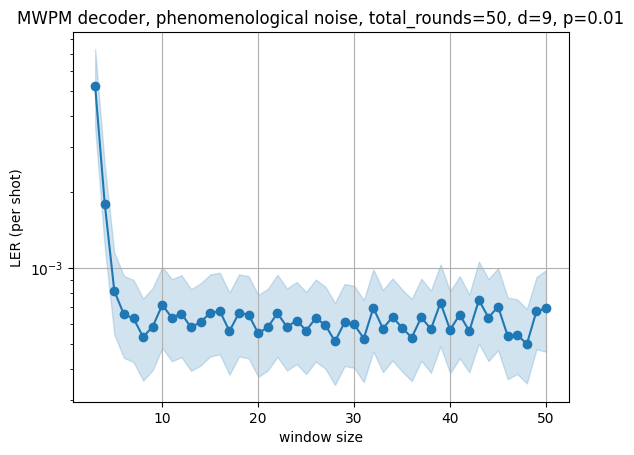

In [8]:
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=sinter_stats,
    x_func=lambda stat: stat.json_metadata["window_size"],
)
ax.set_yscale("log")
ax.grid()
ax.set_ylabel("LER (per shot)")
ax.set_xlabel("window size")
ax.set_title("MWPM decoder, phenomenological noise, total_rounds=50, d=9, p=0.01")